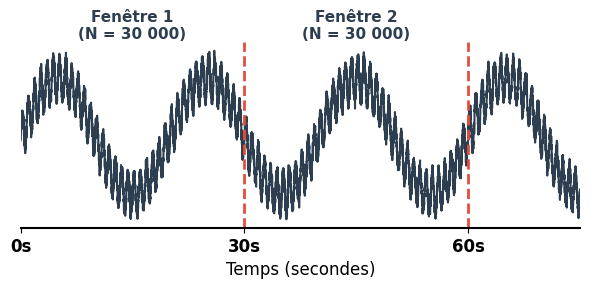

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation d'un faux signal physiologique (Plus court !)
fs = 100  
t_max = 75 # On s'arrête à 75s pour avoir 2 fenêtres complètes et un bout de la 3ème
t = np.arange(0, t_max, 1/fs) 

# Création du signal
onde_lente = 1.5 * np.sin(2 * np.pi * 0.05 * t)
onde_rapide = 0.5 * np.sin(2 * np.pi * 1.2 * t)
bruit = np.random.normal(0, 0.1, len(t))
signal = onde_lente + onde_rapide + bruit

# 2. Configuration du graphique (Format "Colonne de poster")
fig, ax = plt.subplots(figsize=(6, 3)) # Largeur réduite de 10 à 6

# Tracé du signal brut
ax.plot(t, signal, color='#2c3e50', linewidth=1.5, label='Signal Brut')

# 3. Ajout des lignes de découpage pour le fenêtrage
duree_fenetre = 30
for w in range(duree_fenetre, t_max, duree_fenetre):
    ax.axvline(x=w, color='#e74c3c', linestyle='--', linewidth=2)

# 4. Esthétique : Nettoyage pour le poster
ax.set_xlim(0, t_max)
ax.get_yaxis().set_visible(False) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)

# Axe X avec seulement les repères nécessaires
ax.set_xticks([0, 30, 60])
ax.set_xticklabels(['0s', '30s', '60s'], fontsize=12, fontweight='bold')
ax.set_xlabel("Temps (secondes)", fontsize=12)

# Ajout d'annotations directement dans les fenêtres
for i, w in enumerate(range(0, 60, duree_fenetre)):
    # J'ai ajouté l'info N=30000 directement sous le nom de la fenêtre !
    ax.text(w + 15, np.max(signal) + 0.3, f"Fenêtre {i+1}\n(N = 30 000)", 
            horizontalalignment='center', fontsize=11, fontweight='bold', color='#2c3e50')

plt.tight_layout()

# 5. Sauvegarde en Haute Résolution (300 dpi) avec fond transparent
plt.savefig("schema_fenetrage_v2.png", dpi=300, transparent=True)

plt.show()